#Instancia de evaluación:

Esta tarea nos permitirá no solo poner a prueba nuestras habilidades en la construcción de modelos, sino también comprender cómo diferentes enfoques de aprendizaje automático pueden tener un impacto significativo en los resultados.

#Para Árbol de Decisión

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
import seaborn as sns
import graphviz
from sklearn.tree import export_graphviz

In [84]:
# Preparación y Organización de Datos
# Cargar Dataset y mostrar primeras 5 filas
url = '/content/drive/MyDrive/Aprendizaje Automático/Archivos semana 4/student-mat.csv'
df = pd.read_csv(url, sep=";")

# Seleccionar variables para predecir nota final
# Variable Objetivo: G3 (Nota final)
# Variables Predictoras: age, studytime, failures, absences, G1, G2
# Para este modelo simple, elegiremos variables numéricas directas
features = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2']
X = df[features]
y = df['G3']

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [85]:
# Exploración Inicial (EDA)
print("\nInformación del DataFrame:")
df.info()
df.isnull().sum()


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-nu

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [86]:
print("\nDescripción del DataFrame:")
print(df.describe())


Descripción del DataFrame:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   

Para este trabajo, vuelvo a seleccionar el Dataset 'student-mat.csv'. La intención es poder aplicar dos nuevos modelos y poder comparar con los ya resueltos en la clase 4.

El dataset incluye 395 registros con variables como edad, tiempo de estudio, ausencias, apoyo familiar, consumo de alcohol, notas parciales y nota final.

No contiene valores nulos ni faltantes.



---

Mi objetivo es aplicar un modelo de aprendizaje automático para clasificar el rendimiento de estudiantes en tres categorías: Bajo, Medio y Alto.


---
En este caso, voy a utilizar los algoritmos de Arbol de Decisión, que me permite tomar decisiones lógicas basadas en características específicas. Y KNN, que me permite identificar patrones cercanos en conjuntos de datos, es valioso para la clasificación y la regresión.

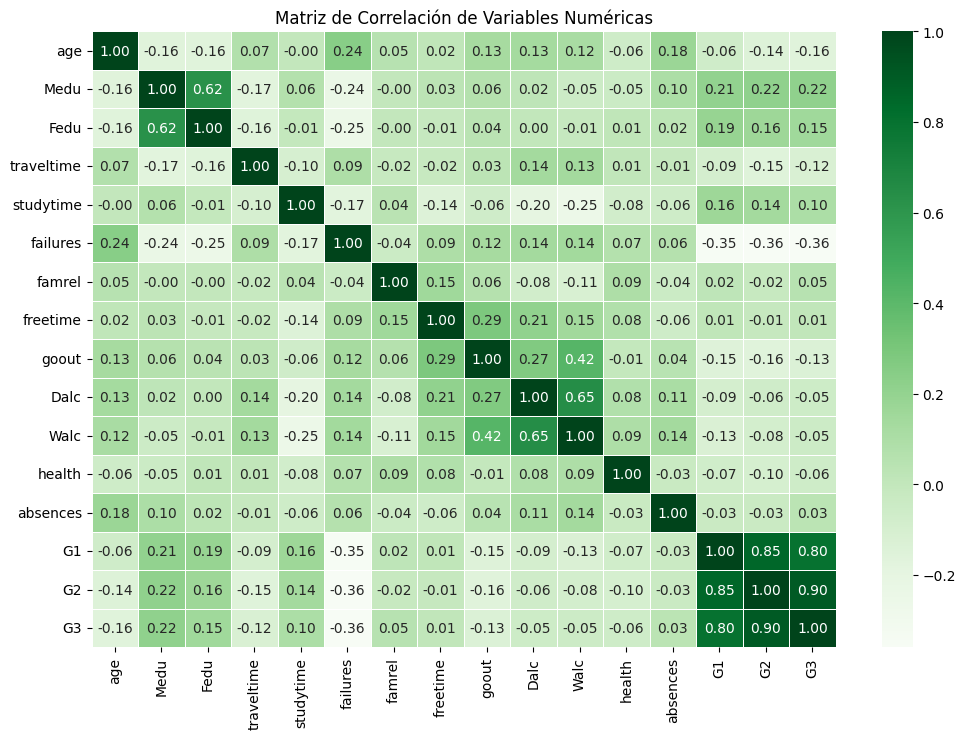

In [87]:
# 2. Matriz de Correlación
plt.figure(figsize=(12, 8))
# Seleccionamos solo columnas numéricas
df_numeric = df.select_dtypes(include=['number'])
correlation = df_numeric.corr()

sns.heatmap(correlation, annot=True, cmap='Greens', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [88]:
# Selección de variables predictoras
features = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2']
X = df[features]
y = df['G3']

In [89]:
# Crear la variable 'Rendimiento', segun la nota final (G3) en categorías.

def clasificar_rendimiento(nota):
    if nota < 10:
        return 'Bajo'
    elif nota < 15:
        return 'Medio'
    else:
        return 'Alto'

df['Rendimiento'] = df['G3'].apply(clasificar_rendimiento)

# Ver distribución
print(df['Rendimiento'].value_counts())

Rendimiento
Medio    192
Bajo     130
Alto      73
Name: count, dtype: int64


In [90]:
# Codificación de las variables categóricas
# (Creo una copia para no mofificar el original)
df_encoded = df.copy()

label_encoder = LabelEncoder()

# Codificar automáticamente
for column in df_encoded.columns:

    if df_encoded[column].dtype == 'object':

        df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

# División en Entrenamiento y Prueba

In [91]:
# 1. Definimos el orden lógico manualmente
mapping = {'Bajo': 0, 'Medio': 1, 'Alto': 2}
df_encoded['Rendimiento'] = df['Rendimiento'].map(mapping)

# Define variables predictoras, X (features) e y (target)
X = df_encoded[features] #(Edad, estudio, ausencias, etc)
y = df_encoded['Rendimiento']

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)



# Crear Modelo Árbol de Decisión

In [92]:
# Crear modelo
tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

# Reporte de Clasificación con nombres reales
# Es importante que el orden en target_names coincida con 0, 1, 2
nombres_clases = ['Bajo', 'Medio', 'Alto']

print("Métricas Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree, target_names=nombres_clases))

Métricas Árbol de Decisión:
              precision    recall  f1-score   support

        Bajo       0.84      0.95      0.89        39
       Medio       0.94      0.88      0.91        58
        Alto       1.00      0.95      0.98        22

    accuracy                           0.92       119
   macro avg       0.93      0.93      0.93       119
weighted avg       0.92      0.92      0.92       119



*Importante:*

**Acurrancy**: Porcentaje de predicciones correctas.

**Precisión**: Que tan correctas son las precisiones.

**Recall**: Cuántos casos reales detectó.

**F1-score**: Equilibrio entre Precisión y Recall.

#Análisis de Resultados

Obtener un 'acurrancy' del 92% me indica un rendimiento considerablemete bueno y mejor que el resultado con KNN. El algoritmo logró clasificar correctamente, poco mas de 9 de cada 10 estudiantes. Se puede interpretar como un modelo sólido y con gran capacidad predictiva.

En cuanto a la interpretación por categoría, el modelo mostró un excelente desempeño en la detección de estudiantes con 'Alto' rendimiento. La precisión de 1.00 nos dice que todas las predicciones fueron excelentes y el 'recall' de 0.95, muestra que el modelo identificó el 95% de estudiantes ('Alto') correctamente.

En 'Medio', los resultados mostraron una alta precisión con 0.94. Detectó correctamente el 0.88 de casos reales (recall).

Y en rendimiento 'Bajo', también se logró un buen resultado. Con una precisión (0.84) y un 'recall de 0.95, que nos indica que se detectan correctamente la mayoría de los casos reales.

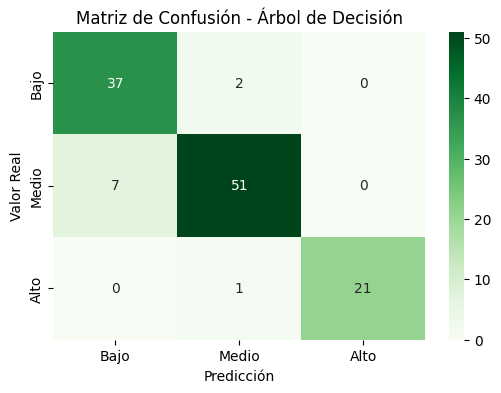

In [93]:
# Crear matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Graficar
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Bajo', 'Medio', 'Alto'],
    yticklabels=['Bajo', 'Medio', 'Alto']
)

plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

*Importante*

La matriz de confusión permite analizar el desempeño del modelo Árbol de Decisión al clasificar el rendimiento académico de los estudiantes en las categorías:

-Bajo

-Medio

-Alto

En la matriz:

-las filas representan los valores reales,

-las columnas representan las predicciones realizadas por el modelo.

Los valores ubicados en la diagonal principal corresponden a las clasificaciones correctas.

#Interpretación de Matriz

La Matriz de Confusión nos muestra un desempeño equilibrado y sólido en las 3 categorías.

Prácticamente no existen confusiones con la categoría 'Alto', 21 estudiantes correctamente clasificados, y solo 1 erróneo.

En la categoría 'Medio' se clasificaron correctamente 51 estudiantes y 3 incorrectamente.

Por último, en la categoría 'Bajo', el rendimiento tambien es bueno, con una clasificación correcta de 37 estudiantes y solo 7 clasificados incorrectamente.

*La mayor parte de las observaciones se concentran en la diagonal principal, lo que refleja un alto nivel de precisión en general.*

#Visualización del Árbol de Decisión

*Importante*

*'LabelEncoder', asigna números basado en el órden alfabético. En este caso, no me facilita la lectura que 'Bajo', quede en medio de las variables 'Alto' y 'Medio'. Por este motivo, investigo la posibilidad de forzar el orden. (También corregido en gráficos anteriores)*


In [94]:
# Definir el orden lógico
mapping = {'Bajo': 0, 'Medio': 1, 'Alto': 2}

# Aplicar al DataFrame
df_encoded['Rendimiento'] = df_encoded['Rendimiento'].map(mapping)

# Ahora, al visualizar el árbol, el orden de class_names será el de tus números:
# 0 -> 'Bajo', 1 -> 'Medio', 2 -> 'Alto'

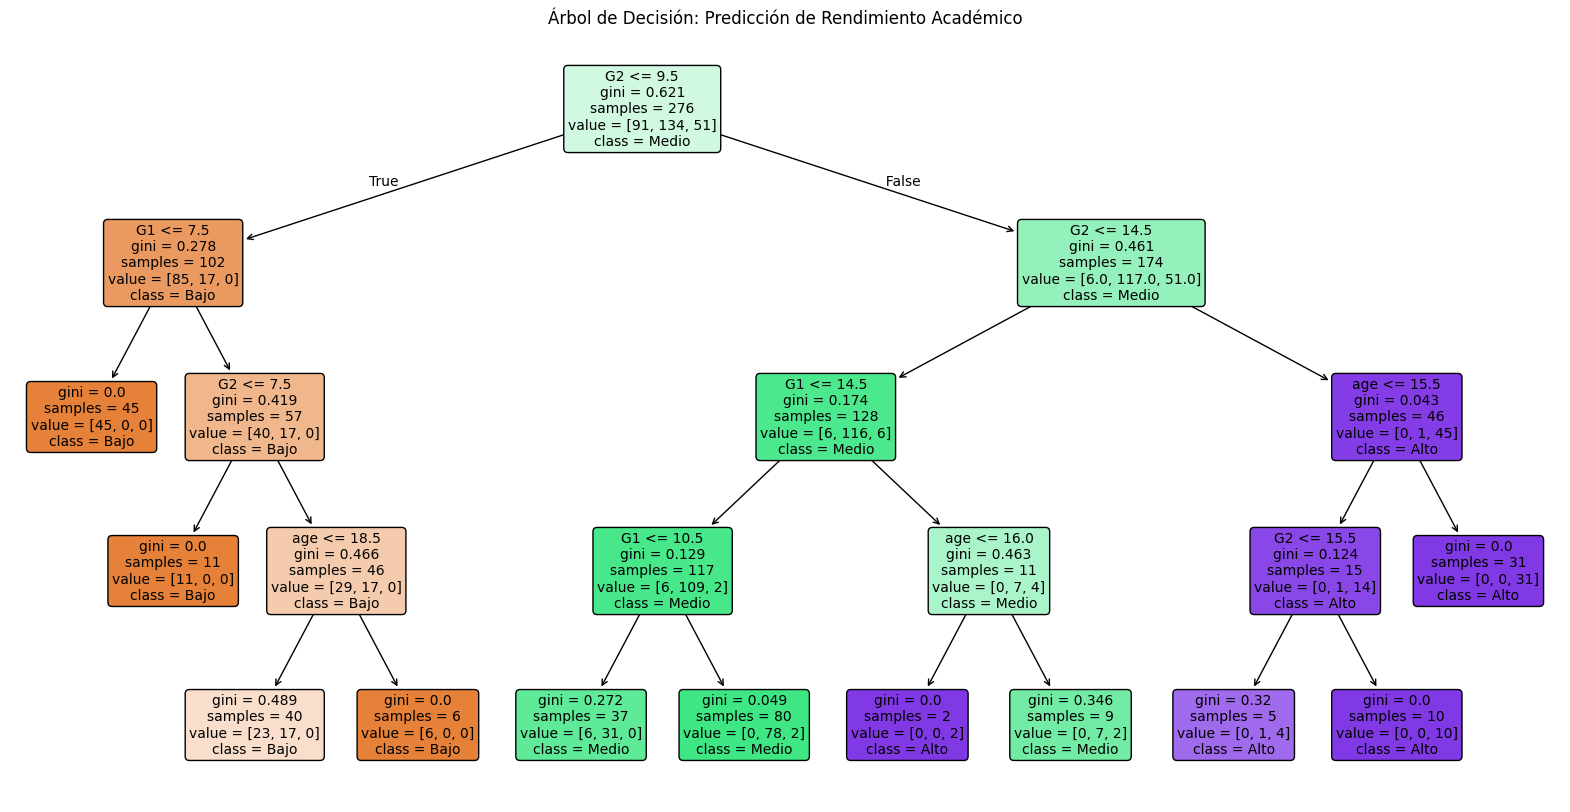

In [95]:
# Configurar el tamaño de la figura
plt.figure(figsize=(20, 10))

# Dibujar el árbol
plot_tree(
    tree,
    feature_names=features,
    class_names=['Bajo', 'Medio', 'Alto'], # Orden forzado en código anterior
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de Decisión: Predicción de Rendimiento Académico")
plt.show()

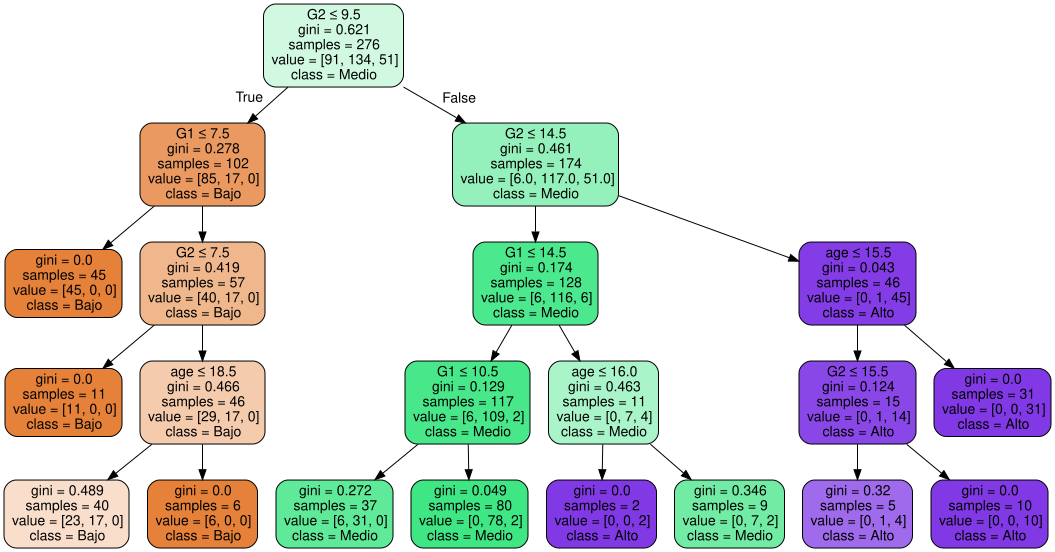

In [96]:
# Visualización usando Graphviz
dot_data = export_graphviz(
    tree, out_file=None,
    feature_names=features,
    class_names=['Bajo', 'Medio', 'Alto'],
    filled=True, rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph.render("arbol_rendimiento") # Guarda un PDF
graph # Muestra el árbol en Jupyter/Colab

*Nota para Estudio*

**filled=True**: Colorea los nodos. Los colores indican la clase predominante. Cuanto más intenso es el color, más "puro" es el nodo (menor índice Gini).

**feature_names**: Sustituye los índices de las columnas por los nombres reales (age, G2, etc.), lo que hace que el árbol sea interpretable para humanos.

**class_names**: Es vital que el orden coincida con cómo el LabelEncoder codificó tus etiquetas. Por defecto, LabelEncoder ordena alfabéticamente. (corregido). 0 'Bajo'; 1 'Medio'; 2 'Alto'.

**max_depth=4**: Como limitamos el árbol en telu código, la visualización no se verá amontonada y se puede seguir la lógica de las notas G1 y G2 fácilmente.

*Para interpretar el árbol con orden lógico (Bajo < Medio < Alto), debemos fijarnos en cómo las variables (features) van dividiendo a los estudiantes a medida que bajamos por las ramas.*

¿Cómo leer cada Nodo?

Cuando mires un cuadro del árbol, verás esto:

Condición (ej. G2 <= 12.5): Si se cumple, vas a la izquierda; si no, a la derecha.

Gini: Mide qué tan mezclados están los alumnos en ese punto. Si es $0$, ese grupo es "puro" (todos pertenecen a la misma categoría).

Samples: Cuántos alumnos de tu X_train cayeron en ese nodo.

Value [x, y, z]: Siguiendo nuestro nuevo orden, verás cuántos hay de cada uno: [Bajo, Medio, Alto].

Class: La categoría que domina en ese nodo (la que el modelo predecirá para cualquiera que llegue ahí).

Análisis de los Colores

Nodos Naranjas/Rojizos: Suelen representar el rendimiento Bajo.

Nodos Verdes/Cian: Suelen representar el rendimiento Medio.

Nodos Púrpura/Azul: Suelen representar el rendimiento Alto.


#Interpretación de Árbol de Decisión

El nodo superior (raíz) divide a los estudiantes segun su nota en G2 (segunda nota parcial), es el filtro principal.

Hacia la izquierda, el árbol agrupa las notas en Bajo/Madio (G2<=9.5), y hacia la derecha las notas mas altas, Medio/Alto (G2>9.5).

El segundo nivel del árbol, usa G1 para detectar consistencia, validar: si un alumno tiene un G2 aceptable, el modelo va a mirar G1 para ver la consistencia.

En el tercer nivel, aparece 'Age', como un factor demográfico. Para alumnos que están en el límite entre dos categorías (medio y alto), la edad podría marcar una diferencia en el dataset.

##Conclusión

El árbol evidencia una relación jerárquica entre las calificaciones parciales y el rendimiento final:
G2 → G1 → edad.

Las notas parciales son predictores más fuertes que la edad, lo que coincide con la lógica educativa: el desempeño previo anticipa el resultado final.

Las regiones con bajo gini (por ejemplo, nodos de 'Alto' y 'Bajo') indican alta confianza en la clasificación, mientras que los nodos 'Medio' presentan mayor mezcla y menor precisión.

Este modelo puede servir para detección temprana de riesgo académico: estudiantes con G1 y G2 bajos podrían, por ejemplo, recibir apoyo adicional.


